In [1]:
# ====================================
# CELL 1: Imports
# ====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# ====================================
# CELL 2: Load Dataset
# ====================================

df = pd.read_csv("dataset/flood.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n")
print(df.head())

print("\nMissing values:\n")
print(df.isnull().sum())

Dataset Shape: (50000, 21)

First 5 rows:

   MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0                 3                   8                6              6   
1                 8                   4                5              7   
2                 3                  10                4              1   
3                 4                   4                2              7   
4                 3                   7                5              2   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             4              4            6          2                      3   
1             7              9            1          5                      5   
2             7              5            4          7                      4   
3             3              4            1          4                      6   
4             5              8            5          2                      7   

   Encroachments  .

In [5]:
# ====================================
# CELL 3: Define Features & Target
# ====================================

target = "FloodProbability"

X = df.drop(columns=[target])
y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (50000, 20)
Target Shape: (50000,)


In [4]:
# ====================================
# CELL 4: Train/Test Split
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (37500, 20)
Test Shape: (12500, 20)


In [5]:
# ====================================
# CELL 5: Baseline Model
# ====================================

base_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

base_model.fit(X_train, y_train)

y_pred = base_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Baseline R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Baseline R²: 0.7319
MAE: 0.0204
RMSE: 0.0259


In [6]:
# ====================================
# CELL 6: Overfitting Check
# ====================================

train_pred = base_model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {r2:.4f}")

Training R²: 0.9632
Testing R²: 0.7319


In [7]:
# ====================================
# CELL 7: Cross Validation
# ====================================

cv_scores = cross_val_score(
    base_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation R² Scores:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))

Cross Validation R² Scores: [0.73492447 0.7387371  0.73659086 0.73472411 0.73393964]
Mean CV R²: 0.7357832355021554


In [8]:
# ====================================
# CELL 8: Hyperparameter Tuning
# ====================================

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [9]:
# ====================================
# CELL 9: Final Model Evaluation
# ====================================

final_pred = best_model.predict(X_test)

final_r2 = r2_score(y_test, final_pred)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print(f"Final R²: {final_r2:.4f}")
print(f"Final MAE: {final_mae:.4f}")
print(f"Final RMSE: {final_rmse:.4f}")

Final R²: 0.7326
Final MAE: 0.0204
Final RMSE: 0.0258


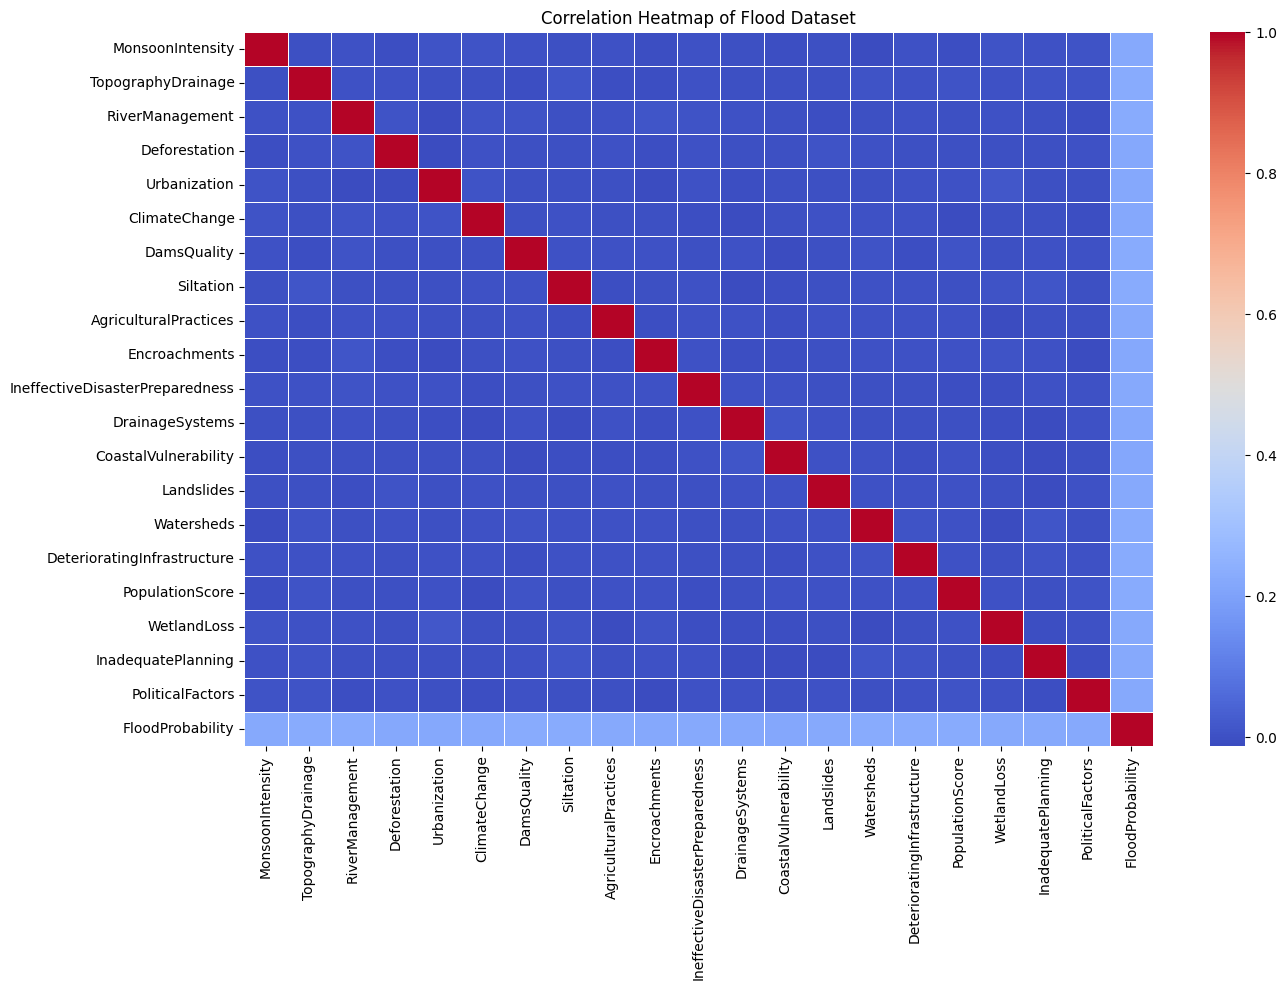

In [10]:
# ====================================
# Correlation Heatmap
# ====================================

plt.figure(figsize=(14,10))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Flood Dataset")
plt.tight_layout()
plt.show()

In [11]:
# ====================================
# Correlation with Target
# ====================================

target_corr = df.corr()["FloodProbability"].sort_values(ascending=False)

print(target_corr)

FloodProbability                   1.000000
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
WetlandLoss                        0.223732
InadequatePlanning                 0.223329
Landslides                         0.222991
AgriculturalPractices              0.221846
ClimateChange                      0.220986
Urbanization                       0.220867
Deforestation                      0.220237
Encroachments                      0.218259
DrainageSystems                    0.217895
CoastalVulnerability               0.215187
Name: FloodProbability, dtype: float64


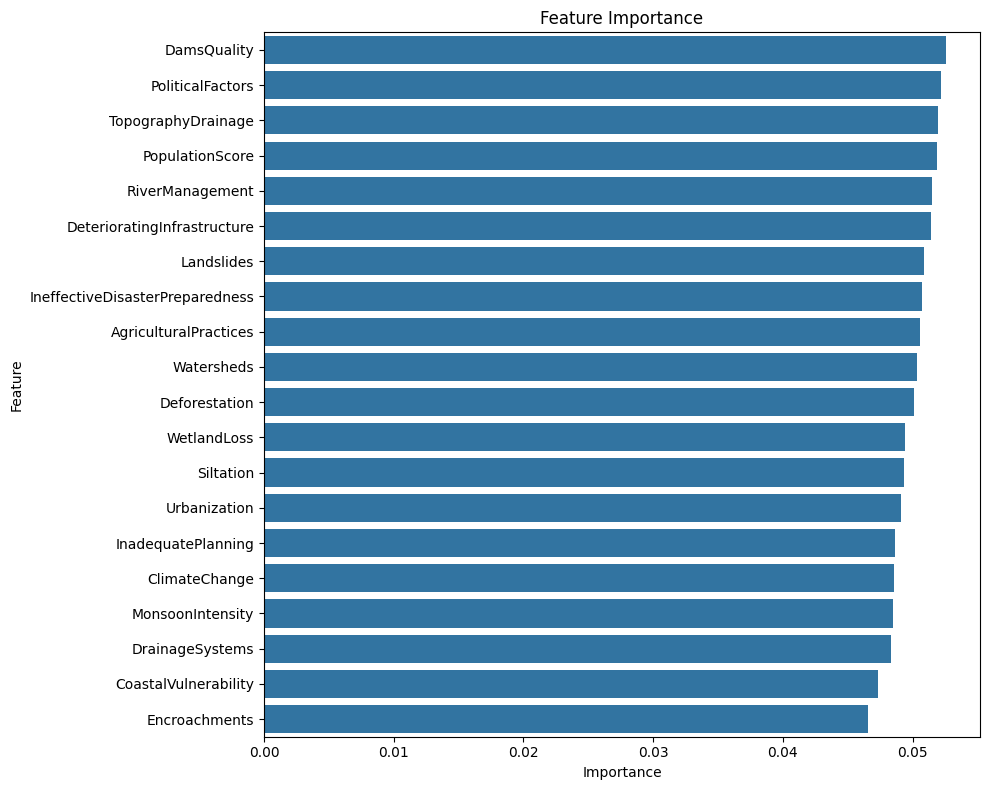

In [15]:
# ====================================
# CELL 10: Feature Importance
# ====================================



importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": base_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [14]:
# ====================================
# CELL 11: Save Model
# ====================================

joblib.dump(best_model, "flood_probability_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [16]:


import joblib

save_path = "C:/Users/lenovo/Downloads/flood_probability_model.pkl"

joblib.dump(base_model, save_path)

print("Model saved successfully at:")
print(save_path)

Model saved successfully at:
C:/Users/lenovo/Downloads/flood_probability_model.pkl
